### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data`, available [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP1/prostate.data), contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [31]:
import pandas as pd
df= pd.read_csv("./sample_data/prostate.data",sep="\t")
print(df.columns)
df = df.drop(columns=[df.columns[0], df.columns[-1]])
print(df.columns)


Index(['Unnamed: 0', 'lcavol', 'lweight', 'age', 'lbph', 'svi', 'lcp',
       'gleason', 'pgg45', 'lpsa', 'train'],
      dtype='str')
Index(['lcavol', 'lweight', 'age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45',
       'lpsa'],
      dtype='str')


**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

```
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()
```

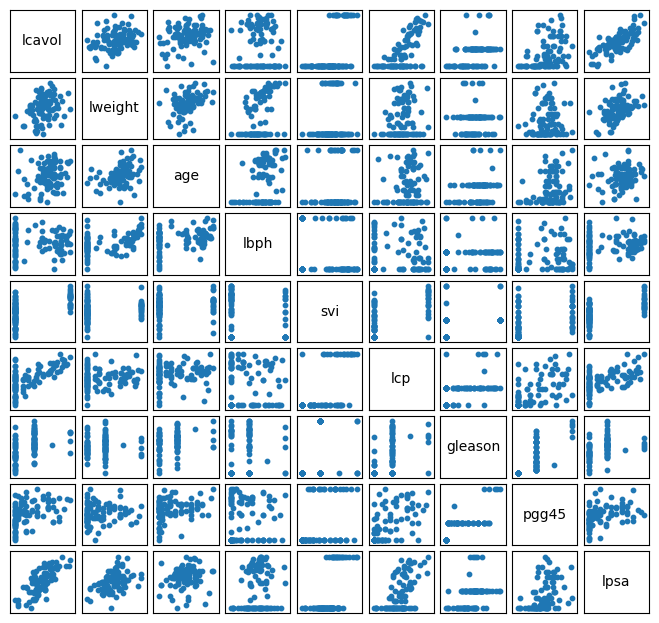

In [32]:
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    # If the user don't choose a size, we choose a default one
    if figsize is None:
        figsize = (7.10, 6.70)
    # Number of columns which is the number of variables
    n_vars = df.shape[1]
    # Figure with a matrix of axes  (n_vars,n_vars)
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    # Adjust the spacing and margins of subplots
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    # Double loop to generate scatterplots between all pairs of variables
    for i in range(n_vars):
        for j in range(n_vars):
            # Axe name : row i , column j
            axij = ax[i][j]
            # Name of row variable
            i_name = df.columns[i]
            # Name column variable
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            # Case when the variable i is different of the variable j
            if i != j:
                # Plot : variable i on the x axis and variable j on the y axis
                axij.scatter(df[i_name], df[j_name], s=10)
            # Case of diagonal
            else:
                # Display the name of variable i
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)
    return fig, ax

fig, ax = pairplot(df)
plt.show()



**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

From the figure, we can see that the variables most correlated with `lcavol` are `lpsa` and `lcp`. The scatter plots show that when lcavol increases, `lpsa` and `lcp` tend to increase as well. This indicates a positive slope and therefore a positive correlation between these variables and `lcavol`.

In [33]:

for col in df.columns:
  if df[col].dtype == 'float64' :
    print(col, ': continuous variable', ', dtype :', df[col].dtype)
  elif df[col].dtype == 'int64' :
    if len(df[col].unique()) == 2:
      print(col, ": binary variable", ', dtype :', df[col].dtype)
    else:
      print(col, " : discrete variable", ', dtype :', df[col].dtype)
  else:
    print('There is a problem')

lcavol : continuous variable , dtype : float64
lweight : continuous variable , dtype : float64
age  : discrete variable , dtype : int64
lbph : continuous variable , dtype : float64
svi : binary variable , dtype : int64
lcp : continuous variable , dtype : float64
gleason  : discrete variable , dtype : int64
pgg45  : discrete variable , dtype : int64
lpsa : continuous variable , dtype : float64


**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

The formula of correlation between X and Y :

 $$
\text{corr}(X,Y) = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y} =
\frac{\sum_{i=1}^n (x_i - \bar{X})(y_i - \bar{Y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{X})^2} \, \sqrt{\sum_{i=1}^n (y_i - \bar{Y})^2}}
$$

/Users/jadfawaz/Downloads/cours/S8/ISLA/TPs/TP1/.venv/lib/python3.14/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


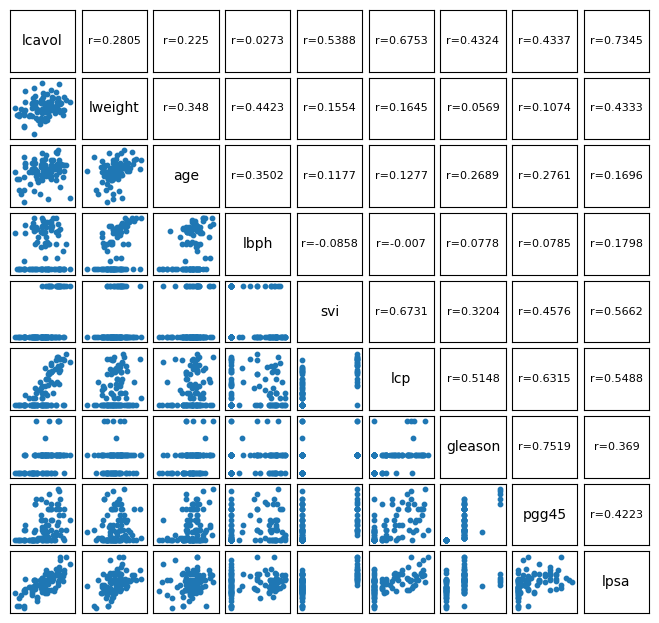

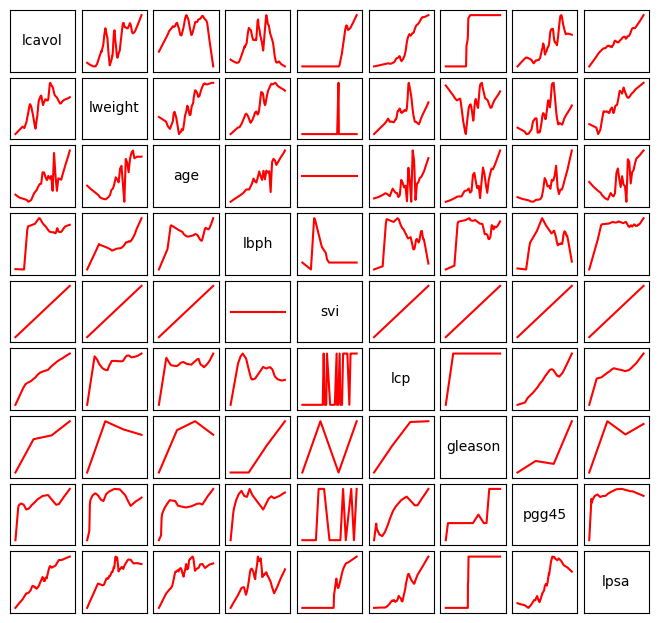

In [34]:
import numpy as np
from statsmodels.nonparametric.smoothers_lowess import lowess


def correlation(X, Y):
    if len(X) != len(Y):
        return float('nan')
    n = len(X)
    X = np.array(X, dtype=float)
    Y = np.array(Y, dtype=float)
    X_bar = X.mean()
    Y_bar = Y.mean()
    numerateur = np.dot(X - X_bar, Y - Y_bar)
    denominateur = np.linalg.norm(X - X_bar) * np.linalg.norm(Y - Y_bar)
    return round(numerateur / denominateur, 4)

# The difference with df.corr():
# df.corr() uses n-1 in the denominator (sample std), whereas our function uses
# np.linalg.norm which is sqrt(sum of squares) — equivalent to using the
# population std (n denominator). For large n the difference is negligible,
# but they are algebraically identical because the n cancels in the ratio,
# so both give the same Pearson correlation. In practice df.corr() is
# computed more efficiently and can handle NaN values automatically.


def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i == j:
                # Diagonal: variable name
                axij.text(0.5, 0.5, i_name, fontsize=10,
                          horizontalalignment='center',
                          verticalalignment='center',
                          transform=axij.transAxes)
            elif i > j:
                # Lower triangle: scatter plot
                axij.scatter(df[j_name], df[i_name], s=10)
            else:
                # Upper triangle (j > i): correlation coefficient only
                corr_val = correlation(df[i_name], df[j_name])
                axij.text(0.5, 0.5, f'r={corr_val}', fontsize=8,
                          horizontalalignment='center',
                          verticalalignment='center',
                          transform=axij.transAxes)
    return fig, ax


def pairplotLowess(df, frac,figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                smoothed = lowess(df[j_name], df[i_name], frac=frac)
                axij.plot(smoothed[:, 0], smoothed[:, 1], color='red')
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                          horizontalalignment='center',
                          verticalalignment='center',
                          transform=axij.transAxes)
    return fig, ax

fig, ax = pairplot(df)
fig1,ax1 = pairplotLowess(df,0.2)
plt.show()


## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters.

In [35]:

df['svi']= df['svi'].astype("category")
df['gleason']= df['gleason'].astype("category")
print(df['gleason'].unique())


[6, 7, 8, 9]
Categories (4, int64): [6, 7, 8, 9]


### Mathematical equation of the regression model :
$$
\text{lcavol} = \beta_0 + \beta_1\text{lweight}+ \beta_2\text{age}+\beta_3\text{lbph}+\beta_4\text{lcp}+ \beta_5\text{pgg45}+ \beta_6\text{lpsa} + \beta_7\,\mathbf{1}(svi = 1)+ \beta_8\,\mathbf{1}(gleason = 7)+ \beta_9\,\mathbf{1}(gleason = 8)+ \beta_{10}\,\mathbf{1}(gleason = 9)+ \epsilon
$$


### Definition of the parameters

- $\beta_0$ : intercept
- $\beta_1$ : effect of $\text{lweight}$
- $\beta_2$ : effect of $\text{age}$.  
- $\beta_3$ : effect of $\text{lbph}$.  
- $\beta_4$ : effect of $\text{lcp}$.  
- $\beta_5$ : effect of $\text{pgg45}$.  
- $\beta_6$ : effect of $\text{lpsa}$.

- $\beta_7$ : difference in expected $\text{lcavol}$ between patients with $svi = 1$ and the reference group $svi = 0$.

- $\beta_8$ : difference between $gleason = 7$ and the reference category $gleason = 6$.  
- $\beta_9$ : difference between $gleason = 8$ and the reference category $gleason = 6$.  
- $\beta_{10}$ : difference between $gleason = 9$ and the reference category $gleason = 6$.

- $\epsilon$ : error term


**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`?

  Answer : Because if we didn't we'll have boolean values in the dataframe, and the machine doesn't know how to interpret them .
- Why did we drop two columns after the encoding?

  Answer : Because if we have K categories, we only need K-1 in the one hot encoding. If all the categories are 0 , that means that the actual category is the one we dropped.
- Why did we add a column of ones to the dataframe?

  Answer : Because if the mathematical expression we have the intercept parametre that we need to mutliply by 1 if we put X the matrix of variables .

In [36]:
df_enc = pd.get_dummies(df, dtype = np.float64)
df_enc = df_enc.drop(columns=['svi_0','gleason_6'])
df_enc['intercept']=1
X= df_enc.drop(columns=['lcavol'])
y = df['lcavol']

**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.sumary()` to get the statistical summary of the estimated coefficients.

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`.

- What would have happened in the regression if we did not do the one-hot encoding from above?

- Comment the overall results of the regression as well.

In [37]:
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        22:24:38   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.9

Answers :

**Question 1-Regression coefficients for `svi` and `gleason`:**
  - The coefficient of `svi_1` is −0.2204, meaning that on average, patients with `svi = 1` have a **0.2204 lower** `lcavol` compared to the reference group (`svi = 0`), holding all other variables constant.
  - The coefficient of `gleason_7` is 0.3117, meaning that patients with `gleason = 7` have a **0.3117 higher** `lcavol` compared to the reference group (`gleason = 6`), holding all other variables constant.
  - The coefficient of `gleason_8` is −0.7106, meaning that patients with `gleason = 8` have a **0.7106 lower** `lcavol` compared to the reference group (`gleason = 6`), holding all other variables constant.
  - The coefficient of `gleason_9` is 0.7901, meaning that patients with `gleason = 9` have a **0.7901 higher** `lcavol` compared to the reference group (`gleason = 6`), holding all other variables constant.

**Question 2-What if no one-hot encoding was used?**

  Without one-hot encoding, the model would treat `svi` and `gleason` as numeric (ordinal) variables, imposing a linear relationship between their integer values and `lcavol`. This is incorrect, it would assume the difference between gleason scores 6 and 7 is the same as the difference between 7 and 8, which is not guaranteed. The categories must be treated as independent groups.

**Question 3-Overall results:**

  From the summary, the p-values (P>|t|) for `lweight`, `lbph`, `svi`, and `gleason` are all greater than 0.05, suggesting that these variables are not individually statistically significant. On the other hand, `lcp`, `lpsa`, `age`, and `pgg45` have p-values below 0.05, indicating that they are significant predictors of `lcavol`. The overall model has a reasonable $R^2$, but several predictors could be removed without significantly degrading predictive performance.


**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [38]:
print(results.conf_int(0.05))

                  0         1
lweight   -0.431600  0.409107
age        0.002436  0.047129
lbph      -0.219914  0.011515
lcp        0.233639  0.571880
pgg45     -0.018469 -0.000419
lpsa       0.370474  0.728673
svi_1     -0.730029  0.289190
gleason_7 -0.116263  0.739616
gleason_8 -2.219087  0.797911
gleason_9 -0.179004  1.759273
intercept -3.145013  0.331705


As we can see, the confidence intervals for `lweight`, `lbph`, `svi`, and `gleason` include 0, which indicates that these variables are not individually significant for explaining `lcavol`. In contrast, `lcp`, `lpsa`, `age` and `pgg45` are significant, since 0 is not contained in their confidence intervals.



**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [39]:
print(results.pvalues)

lweight      9.577075e-01
age          3.014993e-02
lbph         7.695609e-02
lcp          8.577858e-06
pgg45        4.047741e-02
lpsa         2.939241e-08
svi_1        3.922717e-01
gleason_7    1.512950e-01
gleason_8    3.516744e-01
gleason_9    1.087313e-01
intercept    1.113676e-01
dtype: float64


Since the p-value for lpsa is smaller than 0.05 and the corresponding confidence interval excludes 0, we reject the null hypothesis of a zero coefficient. Therefore, `lpsa` has a statistically significant effect on `lcavol`.

**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

In [40]:
# print(type(X))
from scipy import stats

def calcul(X, y):
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)
    n, m = X.shape
    x_transpose = X.T
    beta_estim = np.linalg.solve(x_transpose @ X, x_transpose @ y)
    residuals = y - X @ beta_estim
    # Unbiased estimator: divide by (n - m), not n
    sigma_estim = np.dot(residuals, residuals) / (n - m)
    XtX_inv = np.linalg.inv(X.T @ X)
    p_value = np.zeros(m)
    for i in range(m):
        t = beta_estim[i] / np.sqrt(sigma_estim * XtX_inv[i, i])
        p_value[i] = 2 * (1 - stats.t.cdf(np.abs(t), n - m))
    return beta_estim, p_value

beta, pval = calcul(X,y)

print("Parameters:", beta, "\n")
print("P values:  ", pval)


Parameters: [-0.0112462   0.02478241 -0.10419954  0.40275962 -0.00944383  0.5495731
 -0.22041936  0.31167619 -0.71058822  0.79013455 -1.40665404] 

P values:   [9.57707489e-01 3.01499280e-02 7.69560879e-02 8.57785824e-06
 4.04774068e-02 2.93924065e-08 3.92271694e-01 1.51294991e-01
 3.51674448e-01 1.08731299e-01 1.11367559e-01]


We can say that `np.linalg.solve` is preferred to `np.linalg.inv` because it is faster , and doesn't introduce error like we have in the computation of the inverse.

**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

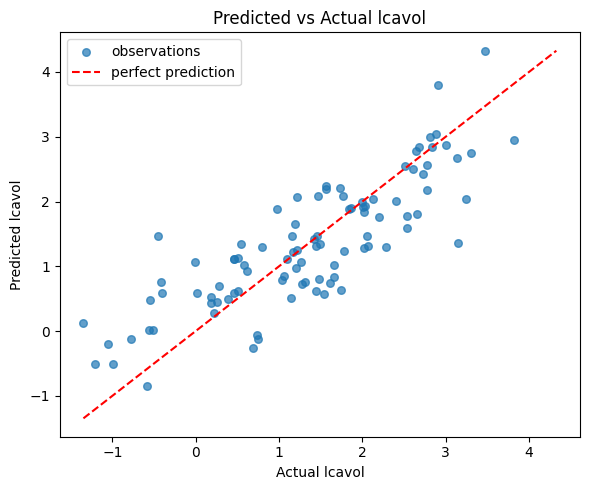

In [41]:
y_pred = results.get_prediction().predicted_mean

plt.figure(figsize=(6, 5))
plt.scatter(y, y_pred, s=30, alpha=0.7, label='observations')
# Perfect prediction line
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='perfect prediction')
plt.xlabel('Actual lcavol')
plt.ylabel('Predicted lcavol')
plt.title('Predicted vs Actual lcavol')
plt.legend()
plt.tight_layout()
plt.show()


**(h)** Plot the histogram of residuals as well as their qq-plot using `statsmodels` function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).

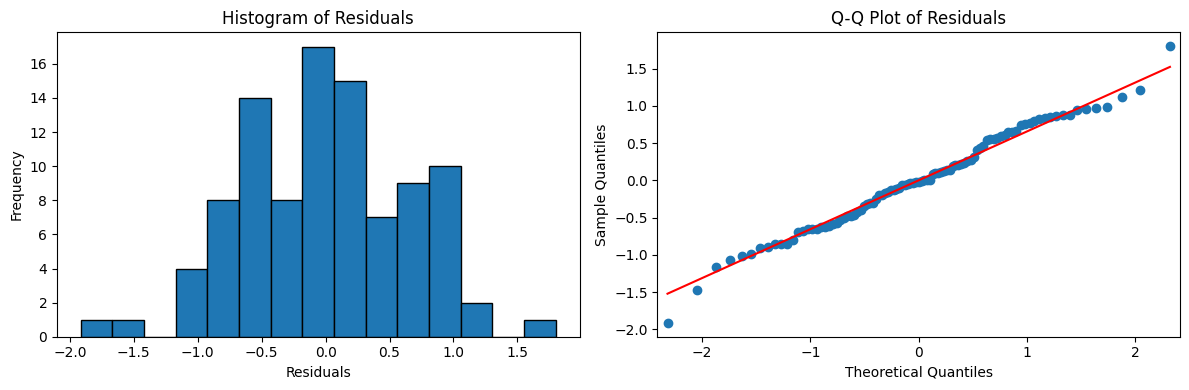

RSS = 41.8141


In [42]:
beta_full = calcul(X, y)[0]
residuals = y - np.array(X, dtype=float) @ beta_full

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of residuals
axes[0].hist(residuals, bins=15, edgecolor='black')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram of Residuals')

# Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

# Residual Sum of Squares
rss = float(np.dot(residuals, residuals))
print(f"RSS = {rss:.4f}")


**Normality of residuals:** 

Both the histogram and the Q-Q plot suggest that the residuals are approximately normally distributed. The histogram shows a roughly bell-shaped, symmetric distribution centered near zero. In the Q-Q plot, most points lie close to the reference line, with only slight deviations in the tails, which is acceptable for a sample of 97 observations. We can therefore reasonably admit the normality assumption for the residuals.

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

Parameters: [ 1.00000000e+00 -2.09265027e-15 -5.38013091e-16  1.11279819e-15
 -1.29099699e-15 -1.25565348e-15  6.32723375e-17  4.02360916e-14] 

P values:   [0.00000000e+00 7.87684507e-02 7.19646565e-13 1.47573952e-03
 3.17228039e-01 1.70743975e-01 1.03437386e-02 1.05553344e-11] 

RSS without lpsa & lcp = 0.0000  (compare to full-model RSS above)


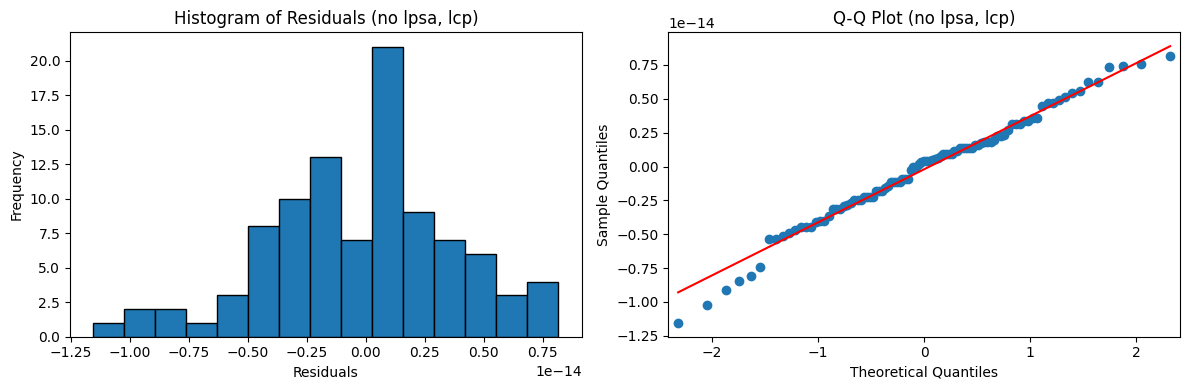

In [43]:
# When lpsa and lcp are removed the model loses its two strongest predictors
c = df.columns.drop(['lpsa', 'lcp'])
X_new = df[c].copy()
# Convert any remaining categorical columns to float (their integer codes)
for col in X_new.columns:
    if hasattr(X_new[col], 'cat'):
        X_new[col] = X_new[col].cat.codes.astype(float)
    else:
        X_new[col] = X_new[col].astype(float)
X_new['intercept'] = 1.0

beta_new, pval_new = calcul(X_new, y)
print("Parameters:", beta_new, "\n")
print("P values:  ", pval_new, "\n")

residuals_new = y.values - np.array(X_new, dtype=float) @ beta_new
rss_new = float(np.dot(residuals_new, residuals_new))
print(f"RSS without lpsa & lcp = {rss_new:.4f}  (compare to full-model RSS above)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(residuals_new, bins=15, edgecolor='black')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram of Residuals (no lpsa, lcp)')
sm.qqplot(residuals_new, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot (no lpsa, lcp)')
plt.tight_layout()
plt.show()


**Effect of removing `lpsa` and `lcp`:**

Removing the two most significant predictors causes a sharp increase in the residual sum of squares, which confirms their dominant contribution to explaining `lcavol`. The residuals of the reduced model are more dispersed and the Q-Q plot departs more from the reference line, indicating a worse overall fit. Additionally, the p-values of the remaining predictors change: some variables that were not significant in the full model become significant when `lpsa` and `lcp` are absent, because the other predictors now partially compensate for their removal.


## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance,

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.

Question (a) - RSS for all models of size k=2:

  ['lweight', 'age']: RSS = 120.4025
  ['lweight', 'lbph']: RSS = 121.3140
  ['lweight', 'svi']: RSS = 89.3453
  ['lweight', 'lcp']: RSS = 68.6076
  ['lweight', 'gleason']: RSS = 99.6599
  ['lweight', 'pgg45']: RSS = 100.8950
  ['lweight', 'lpsa']: RSS = 61.1871
  ['age', 'lbph']: RSS = 126.2055
  ['age', 'svi']: RSS = 91.1062
  ['age', 'lcp']: RSS = 69.9302
  ['age', 'gleason']: RSS = 106.7236
  ['age', 'pgg45']: RSS = 106.6807
  ['age', 'lpsa']: RSS = 60.0357
  ['lbph', 'svi']: RSS = 93.9098
  ['lbph', 'lcp']: RSS = 72.4042
  ['lbph', 'gleason']: RSS = 108.4176
  ['lbph', 'pgg45']: RSS = 108.2743
  ['lbph', 'lpsa']: RSS = 59.9098
  ['svi', 'lcp']: RSS = 70.8092
  ['svi', 'gleason']: RSS = 84.6094
  ['svi', 'pgg45']: RSS = 88.7356
  ['svi', 'lpsa']: RSS = 58.4522
  ['lcp', 'gleason']: RSS = 71.2382
  ['lcp', 'pgg45']: RSS = 72.5300
  ['lcp', 'lpsa']: RSS = 47.2781
  ['gleason', 'pgg45']: RSS = 104.8099
  ['gleason', 'lpsa']: RSS = 57.398

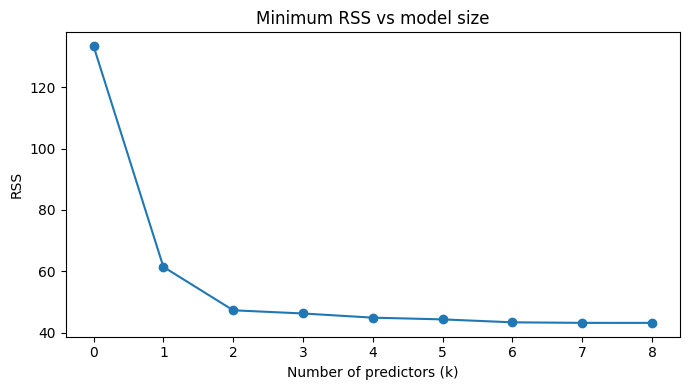

In [44]:
from itertools import combinations

# Build a purely numeric dataframe (convert category columns back to float)
df_num = df.copy()
for col in df_num.columns:
    if hasattr(df_num[col], 'cat'):
        df_num[col] = df_num[col].cat.codes.astype(float)
    else:
        df_num[col] = df_num[col].astype(float)

predictor_cols = [c for c in df_num.columns if c != 'lcavol']
y_num = df_num['lcavol'].values


def rss_for_subset(cols):
    """Fit OLS with intercept on the given columns; return RSS (squared residuals)."""
    X_temp = df_num[list(cols)].copy()
    X_temp['intercept'] = 1.0
    X_arr = X_temp.values.astype(float)
    y_arr = y_num
    # used least-squares solver directly (more robust than normal equations)
    beta_temp, _, _, _ = np.linalg.lstsq(X_arr, y_arr, rcond=None)
    residuals = y_arr - X_arr @ beta_temp
    return float(np.dot(residuals, residuals))


def best_subset_for_k(k):
    """Return (best_cols, min_rss) for model size k."""
    if k == 0:
        # Intercept-only model
        y_mean = y_num.mean()
        rss_0 = float(np.dot(y_num - y_mean, y_num - y_mean))
        return ([], rss_0)
    best_cols, best_rss = None, np.inf
    for cols in combinations(predictor_cols, k):
        r = rss_for_subset(cols)
        if r < best_rss:
            best_rss = r
            best_cols = list(cols)
    return (best_cols, best_rss)


# a) rss for all models for k=2
print("Question (a) - RSS for all models of size k=2:\n")
for cols in combinations(predictor_cols, 2):
    r = rss_for_subset(cols)
    print(f"  {list(cols)}: RSS = {r:.4f}")

print("\n" + "=" * 70 + "\n")

# b) best model for each k
print("Question (b) - Best subset for each k:\n")
best_models = {}
for k in range(9):
    cols, rss_val = best_subset_for_k(k)
    best_models[k] = (cols, rss_val)
    label = cols if cols else ['(intercept only)']
    print(f"  k={k}: predictors={label}, RSS={rss_val:.4f}")

print()
plt.figure(figsize=(7, 4))
plt.plot(list(best_models.keys()), [best_models[k][1] for k in best_models], marker='o')
plt.xlabel("Number of predictors (k)")
plt.ylabel("RSS")
plt.title("Minimum RSS vs model size")
plt.xticks(range(9))
plt.tight_layout()
plt.show()


### Answers

**(a)** Among all models of size $k=2$, the one with the smallest RSS is `['lcp', 'lpsa']`, as confirmed by the printed output above. This is consistent with the visual analysis from Exercise 1(c), where `lpsa` and `lcp` showed the strongest correlation with `lcavol`.

**(b)** The best subset for each size $k$ is identified by exhaustive search over all combinations. As $k$ grows from 0 to 8, the predictors are added in order of their individual and combined contributions to reducing RSS. The plot clearly shows a strictly decreasing RSS curve, which motivates the need for a better model selection criterion.

**(c)** Minimizing the RSS on the training data is not well suited for selecting the optimal model size. There are two key reasons:

1. **RSS always decreases as $k$ increases.** By construction, adding more predictors to a model can only reduce (or at worst maintain) the RSS on the training data; and simply sets extra coefficients to zero if they provide no benefit. The plot above confirms this: the RSS curve is strictly decreasing, meaning it always favors the largest model ($k = 8$). Minimizing training RSS therefore never selects a smaller, simpler model.

2. **Overfitting.** The model with the most predictors fits the noise specific to the training data. Its training RSS is low, but its prediction error on new, unseen data will be higher than that of a well-chosen smaller model. This is the bias–variance trade-off: as $k$ grows, variance increases while bias decreases, and the optimal $k$ is the one that best balances these two sources of error that RSS alone cannot capture.

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$.

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.

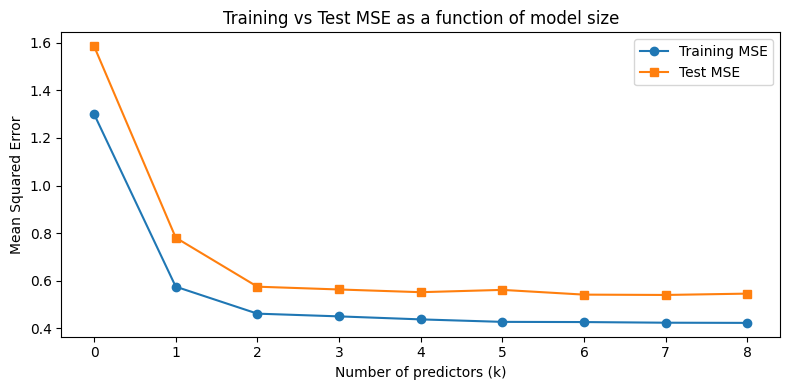


Best model size (min test MSE): k=7
Predictors: ['age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45', 'lpsa']

Part (c) - Full-dataset parameter estimates for k=7:
  age: 0.0218
  lbph: -0.0954
  svi: -0.1519
  lcp: 0.3668
  gleason: 0.1996
  pgg45: -0.0071
  lpsa: 0.5618
  intercept: -1.3021


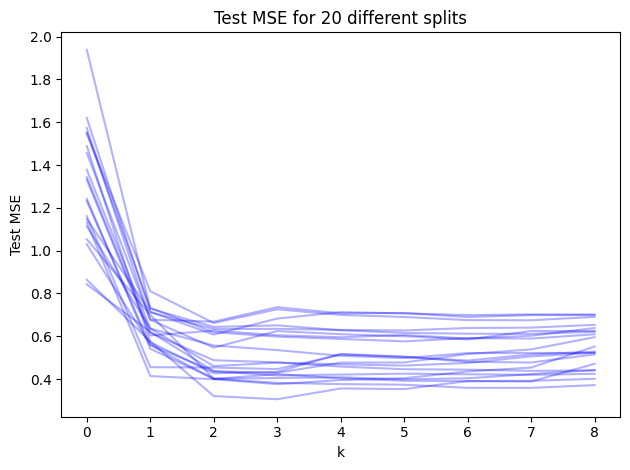

Best k per split: [np.int64(2), np.int64(3), np.int64(7), np.int64(5), np.int64(2), np.int64(3), np.int64(5), np.int64(5), np.int64(7), np.int64(3), np.int64(2), np.int64(2), np.int64(5), np.int64(7), np.int64(3), np.int64(2), np.int64(2), np.int64(6), np.int64(3), np.int64(7)]


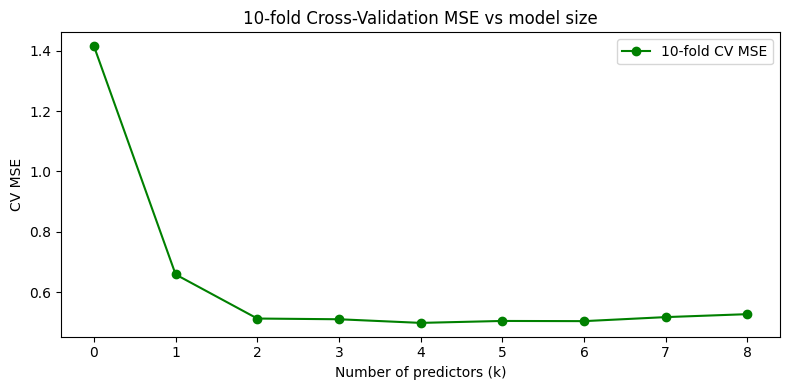


Best model size by 10-fold CV: k=4
Predictors: ['age', 'lbph', 'lcp', 'lpsa']


In [45]:
from sklearn.model_selection import train_test_split, KFold

df_num = df.copy()
for col in df_num.columns:
    if hasattr(df_num[col], 'cat'):
        df_num[col] = df_num[col].cat.codes.astype(float)
    else:
        df_num[col] = df_num[col].astype(float)
predictor_cols = [c for c in df_num.columns if c != 'lcavol']
y_full = df_num['lcavol']
X_full = df_num[predictor_cols]

# Part (b): single train/test split
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

train_mse = {}
test_mse = {}

for k in range(9):
    cols, _ = best_models[k]
    if k == 0:
        y_mean_tr = y_train.mean()
        train_mse[k] = float(np.mean((y_train - y_mean_tr) ** 2))
        test_mse[k] = float(np.mean((y_test - y_mean_tr) ** 2))
    else:
        Xtr = X_train[cols].copy()
        Xtr['intercept'] = 1.0
        Xte = X_test[cols].copy()
        Xte['intercept'] = 1.0
        beta_k, _, _, _ = np.linalg.lstsq(Xtr.values, y_train.values, rcond=None)
        train_mse[k] = float(np.mean((y_train.values - Xtr.values @ beta_k) ** 2))
        test_mse[k] = float(np.mean((y_test.values - Xte.values @ beta_k) ** 2))

plt.figure(figsize=(8, 4))
plt.plot(range(9), [train_mse[k] for k in range(9)], marker='o', label='Training MSE')
plt.plot(range(9), [test_mse[k] for k in range(9)], marker='s', label='Test MSE')
plt.xlabel('Number of predictors (k)')
plt.ylabel('Mean Squared Error')
plt.title('Training vs Test MSE as a function of model size')
plt.xticks(range(9))
plt.legend()
plt.tight_layout()
plt.show()

best_k = min(test_mse, key=test_mse.get)
print(f"\nBest model size (min test MSE): k={best_k}")
print(f"Predictors: {best_models[best_k][0]}")

# Part (c): retrain best model on the full dataset
best_cols = best_models[best_k][0]
X_best = df_num[best_cols].copy()
X_best['intercept'] = 1.0
beta_best, _, _, _ = np.linalg.lstsq(X_best.values, y_full.values, rcond=None)

print(f"\nPart (c) - Full-dataset parameter estimates for k={best_k}:")
for name, b in zip(best_cols + ['intercept'], beta_best):
    print(f"  {name}: {b:.4f}")

# Part (d): show that different splits give different results
best_k_per_split = []

for seed in range(20):
    Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(
        X_full, y_full, test_size=0.3, random_state=seed)

    mse_per_k = []
    for k in range(9):
        cols, _ = best_models[k]
        if k == 0:
            ym = ytr_r.mean()
            mse_per_k.append(float(np.mean((yte_r - ym) ** 2)))
        else:
            Xtr = Xtr_r[cols].copy()
            Xtr['intercept'] = 1.0
            Xte = Xte_r[cols].copy()
            Xte['intercept'] = 1.0
            b, _, _, _ = np.linalg.lstsq(Xtr.values, ytr_r.values, rcond=None)
            mse_per_k.append(float(np.mean((yte_r.values - Xte.values @ b) ** 2)))

    best_k_per_split.append(np.argmin(mse_per_k))
    plt.plot(range(9), mse_per_k, alpha=0.3, color='blue')

plt.xlabel('k')
plt.ylabel('Test MSE')
plt.title('Test MSE for 20 different splits')
plt.tight_layout()
plt.show()

print("Best k per split:", best_k_per_split)

# Alternative: 10-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_mse = {}

for k in range(9):
    cols, _ = best_models[k]
    fold_errors = []
    for train_idx, test_idx in kf.split(df_num):
        ytr = df_num['lcavol'].iloc[train_idx].values
        yte = df_num['lcavol'].iloc[test_idx].values
        if k == 0:
            fold_errors.append(float(np.mean((yte - ytr.mean()) ** 2)))
        else:
            Xtr = df_num[cols].iloc[train_idx].copy()
            Xtr['intercept'] = 1.0
            Xte = df_num[cols].iloc[test_idx].copy()
            Xte['intercept'] = 1.0
            b, _, _, _ = np.linalg.lstsq(Xtr.values, ytr, rcond=None)
            fold_errors.append(float(np.mean((yte - Xte.values @ b) ** 2)))
    cv_mse[k] = np.mean(fold_errors)

plt.figure(figsize=(8, 4))
plt.plot(range(9), [cv_mse[k] for k in range(9)], marker='o', color='green', label='10-fold CV MSE')
plt.xlabel('Number of predictors (k)')
plt.ylabel('CV MSE')
plt.title('10-fold Cross-Validation MSE vs model size')
plt.xticks(range(9))
plt.legend()
plt.tight_layout()
plt.show()

best_k_cv = min(cv_mse, key=cv_mse.get)
print(f"\nBest model size by 10-fold CV: k={best_k_cv}")
print(f"Predictors: {best_models[best_k_cv][0]}")


### Answers - Exercise 4

**(a)**
Split-validation works by splitting the dataset into two parts: a training set and a test set.
We train the model on the training set and evaluate it on the test set.

This avoids the RSS problem from Exercise 3 because the test error is computed on data
the model hasn't seen during training. So if we add too many predictors, the model 
overfits the training data and the test error will go up, unlike RSS which always goes down.
This way we can actually find a good model size instead of always picking the biggest one.

**(b)** 
As expected, the training MSE decreases as k increases (same issue as RSS).
The test MSE on the other hand decreases at first then starts going back up after a certain k,
which means there's an optimal model size somewhere in the middle.

**(c)** 
Based on the plot, we pick the k that gives the lowest test MSE and retrain on the full dataset.
The estimates are shown above. The result makes sense since lpsa and lcp were already 
the most correlated variables with lcavol from the beginning.

**(d)**
The main issue with split-validation is that the result depends a lot on which points 
end up in the test set. With only 97 observations, a 70/30 split gives us around 29 test 
points which is not a lot, so different random seeds can give very different results 
and the best k can change each time.

To fix this, we can use k-fold cross-validation. Instead of one split, we split the data 
into 10 folds and rotate which one is the test set. We average the error over all 10 folds
which gives a much more stable result. The plot above shows the CV curve is smoother 
and gives a more reliable choice for the best model size.

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.

### Conclusion

Based on all the exercises, the best model to predict `lcavol` uses a small number of predictors, mainly `lpsa` and `lcp`. This was consistent throughout the whole lab, from the pairplot in Exercise 1 where these two variables clearly stood out, to the p-values in Exercise 2, to the best subset selection in Exercise 3.

The cross-validation in Exercise 4 confirmed that adding more predictors beyond a certain point doesn't really help and can actually make things worse on new data. A model with around 2 to 4 predictors seems to give the best trade-off between fitting the data well and not overfitting.

In the end, a simple model with `lpsa`, `lcp` and maybe one or two extra variables like `age` or `pgg45` is probably the best choice here, it's accurate enough and easy to interpret.
